#Module 1 — Data Cleaning & Feature Engineering  (3–4 hours)
Goal:  Load the raw CSV, handle missing values, and engineer usable numeric features
Difficulty:  Beginner-friendly but detail-heavy

* Tasks
1.	Load netflix_titles.csv and inspect with .info(), .isnull().sum(), .describe()
2.	Fill missing director, cast, and country with 'Unknown' (do not drop rows — too much data loss)
3.	Convert date_added to datetime using pd.to_datetime(errors='coerce')
4.	Extract year_added and month_added from date_added
5.	Split duration into two new columns based on type: duration_minutes (for Movies) and duration_seasons (for TV Shows) — use str.extract() with a regex to pull the number
6.	Create a primary_country column by taking only the first country listed (country.split(',')[0])
7.	Create a primary_genre column similarly from listed_in
8.	Save the cleaned DataFrame to outputs/netflix_cleaned.csv


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
n=pd.read_csv("/content/netflix_titles.csv")
n.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6234 entries, 0 to 6233
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       6234 non-null   int64 
 1   type          6234 non-null   object
 2   title         6234 non-null   object
 3   director      4265 non-null   object
 4   cast          5664 non-null   object
 5   country       5758 non-null   object
 6   date_added    6223 non-null   object
 7   release_year  6234 non-null   int64 
 8   rating        6224 non-null   object
 9   duration      6234 non-null   object
 10  listed_in     6234 non-null   object
 11  description   6234 non-null   object
dtypes: int64(2), object(10)
memory usage: 584.6+ KB


In [10]:
n.isnull().sum()

,0
show_id,0
type,0
title,0
director,1969
cast,570
country,476
date_added,11
release_year,0
rating,10
duration,0


In [11]:
n.dropna(inplace=True)
n.fillna(0)



,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China","September 9, 2019",2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...
4,80125979,Movie,#realityhigh,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,"September 8, 2017",2017,TV-14,99 min,Comedies,When nerdy high schooler Dani finally attracts...
6,70304989,Movie,Automata,Gabe Ibáñez,"Antonio Banderas, Dylan McDermott, Melanie Gri...","Bulgaria, United States, Spain, Canada","September 8, 2017",2014,R,110 min,"International Movies, Sci-Fi & Fantasy, Thrillers","In a dystopian future, an insurance adjuster f..."
7,80164077,Movie,Fabrizio Copano: Solo pienso en mi,"Rodrigo Toro, Francisco Schultz",Fabrizio Copano,Chile,"September 8, 2017",2017,TV-MA,60 min,Stand-Up Comedy,Fabrizio Copano takes audience participation t...
9,70304990,Movie,Good People,Henrik Ruben Genz,"James Franco, Kate Hudson, Tom Wilkinson, Omar...","United States, United Kingdom, Denmark, Sweden","September 8, 2017",2014,R,90 min,"Action & Adventure, Thrillers",A struggling couple can't believe their luck w...
...,...,...,...,...,...,...,...,...,...,...,...,...
6142,80063224,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"August 30, 2019",2019,TV-PG,7 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
6158,80164216,TV Show,Miraculous: Tales of Ladybug & Cat Noir,Thomas Astruc,"Cristina Vee, Bryce Papenbrook, Keith Silverst...","France, South Korea, Japan","August 2, 2019",2018,TV-Y7,4 Seasons,"Kids' TV, TV Action & Adventure","When Paris is in peril, Marinette becomes Lady..."
6167,80115328,TV Show,Sacred Games,"Vikramaditya Motwane, Anurag Kashyap","Saif Ali Khan, Nawazuddin Siddiqui, Radhika Ap...","India, United States","August 15, 2019",2019,TV-MA,2 Seasons,"Crime TV Shows, International TV Shows, TV Dramas",A link in their pasts leads an honest cop to a...
6182,80176842,TV Show,Men on a Mission,Jung-ah Im,"Ho-dong Kang, Soo-geun Lee, Sang-min Lee, Youn...",South Korea,"April 9, 2019",2019,TV-14,4 Seasons,"International TV Shows, Korean TV Shows, Stand...",Male celebs play make-believe as high schooler...


In [12]:
n[['director','cast','country']].fillna('Unknown')

,director,cast,country
0,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China"
4,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States
6,Gabe Ibáñez,"Antonio Banderas, Dylan McDermott, Melanie Gri...","Bulgaria, United States, Spain, Canada"
7,"Rodrigo Toro, Francisco Schultz",Fabrizio Copano,Chile
9,Henrik Ruben Genz,"James Franco, Kate Hudson, Tom Wilkinson, Omar...","United States, United Kingdom, Denmark, Sweden"
...,...,...,...
6142,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom
6158,Thomas Astruc,"Cristina Vee, Bryce Papenbrook, Keith Silverst...","France, South Korea, Japan"
6167,"Vikramaditya Motwane, Anurag Kashyap","Saif Ali Khan, Nawazuddin Siddiqui, Radhika Ap...","India, United States"
6182,Jung-ah Im,"Ho-dong Kang, Soo-geun Lee, Sang-min Lee, Youn...",South Korea


In [13]:
n.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


In [14]:
n.duplicated().sum()

np.int64(0)

In [15]:
n['date_added'] = pd.to_datetime(n['date_added'], errors='coerce')

In [16]:
n['year_added'] = n['date_added'].dt.year
n['month_added'] = n['date_added'].dt.month

In [17]:
n['duration']

,duration
0,90 min
4,99 min
6,110 min
7,60 min
9,90 min
...,...
6142,7 Seasons
6158,4 Seasons
6167,2 Seasons
6182,4 Seasons


In [18]:
n['duration_seasons'] = n['duration'].str.extract(r'(\d+)\s+Season')
n['duration_time'] = n['duration'].str.extract(r'(\d+)\s+min')

 * + (r'(\d+)\s+Season')--- it means
1. r ' ' (raw string)
2. It tells Python:
"Treat backslashes (\) as they are."
 This is commonly used with regular expressions.
3. (\d+)---
* \d means any digit (0–9).
* '+' means one or more.
4. \s+ ---
* \s means whitespace (space, tab, etc.).
* '+' means one or more spaces.

* + (r'(\d+)\s+min')
1. (\d+)     → extract one or more digits
2. \s+       → one or more spaces
3. min       → the word "min"


In [19]:
n.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3774 entries, 0 to 6213
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   show_id           3774 non-null   int64         
 1   type              3774 non-null   object        
 2   title             3774 non-null   object        
 3   director          3774 non-null   object        
 4   cast              3774 non-null   object        
 5   country           3774 non-null   object        
 6   date_added        3743 non-null   datetime64[ns]
 7   release_year      3774 non-null   int64         
 8   rating            3774 non-null   object        
 9   duration          3774 non-null   object        
 10  listed_in         3774 non-null   object        
 11  description       3774 non-null   object        
 12  year_added        3743 non-null   float64       
 13  month_added       3743 non-null   float64       
 14  duration_seasons  96 non-null

In [20]:
n['country']

,country
0,"United States, India, South Korea, China"
4,United States
6,"Bulgaria, United States, Spain, Canada"
7,Chile
9,"United States, United Kingdom, Denmark, Sweden"
...,...
6142,United Kingdom
6158,"France, South Korea, Japan"
6167,"India, United States"
6182,South Korea


In [21]:
n['primary_country']=n['country'].str.split(',').str[0]

In [22]:
n.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3774 entries, 0 to 6213
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   show_id           3774 non-null   int64         
 1   type              3774 non-null   object        
 2   title             3774 non-null   object        
 3   director          3774 non-null   object        
 4   cast              3774 non-null   object        
 5   country           3774 non-null   object        
 6   date_added        3743 non-null   datetime64[ns]
 7   release_year      3774 non-null   int64         
 8   rating            3774 non-null   object        
 9   duration          3774 non-null   object        
 10  listed_in         3774 non-null   object        
 11  description       3774 non-null   object        
 12  year_added        3743 non-null   float64       
 13  month_added       3743 non-null   float64       
 14  duration_seasons  96 non-null

In [23]:
n['listed_in']

,listed_in
0,"Children & Family Movies, Comedies"
4,Comedies
6,"International Movies, Sci-Fi & Fantasy, Thrillers"
7,Stand-Up Comedy
9,"Action & Adventure, Thrillers"
...,...
6142,"British TV Shows, Reality TV"
6158,"Kids' TV, TV Action & Adventure"
6167,"Crime TV Shows, International TV Shows, TV Dramas"
6182,"International TV Shows, Korean TV Shows, Stand..."


In [24]:
n['primary_genre']=n['listed_in'].str.split(',').str[0]

In [25]:
n.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3774 entries, 0 to 6213
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   show_id           3774 non-null   int64         
 1   type              3774 non-null   object        
 2   title             3774 non-null   object        
 3   director          3774 non-null   object        
 4   cast              3774 non-null   object        
 5   country           3774 non-null   object        
 6   date_added        3743 non-null   datetime64[ns]
 7   release_year      3774 non-null   int64         
 8   rating            3774 non-null   object        
 9   duration          3774 non-null   object        
 10  listed_in         3774 non-null   object        
 11  description       3774 non-null   object        
 12  year_added        3743 non-null   float64       
 13  month_added       3743 non-null   float64       
 14  duration_seasons  96 non-null

In [26]:
n['primary_genre']

,primary_genre
0,Children & Family Movies
4,Comedies
6,International Movies
7,Stand-Up Comedy
9,Action & Adventure
...,...
6142,British TV Shows
6158,Kids' TV
6167,Crime TV Shows
6182,International TV Shows


In [27]:
import os

output_dir = "outputs"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

n.to_csv(os.path.join(output_dir, "netflix_cleaned.csv"), index=False)

#Module 2 — Content Type & Time Trend Analysis  (2–3 hours)
Goal:  Analyze how Netflix's catalog composition has changed over time
Difficulty:  Intermediate

* Tasks
9.	Compute the overall Movie vs TV Show split using value_counts() and a pie chart
10.	Group by year_added and type to get content added per year, per type
11.	Plot a line chart: number of titles added per year, with two lines (Movies, TV Shows)
12.	Compute and plot the percentage of TV Shows over time (year_added) to show Netflix's strategic shift toward original series
13.	Find and annotate the year with the highest content addition (likely 2019 or 2020)
14.	Compute average release_year vs date_added gap (how 'old' is content when Netflix adds it)

* + Analysis Questions Students Should Answer
*	In which year did Netflix add the most content?
*	Has the ratio of TV Shows to Movies increased or decreased over time?
*	Does Netflix mostly add recently-released content or older catalog titles?


In [28]:
n.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3774 entries, 0 to 6213
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   show_id           3774 non-null   int64         
 1   type              3774 non-null   object        
 2   title             3774 non-null   object        
 3   director          3774 non-null   object        
 4   cast              3774 non-null   object        
 5   country           3774 non-null   object        
 6   date_added        3743 non-null   datetime64[ns]
 7   release_year      3774 non-null   int64         
 8   rating            3774 non-null   object        
 9   duration          3774 non-null   object        
 10  listed_in         3774 non-null   object        
 11  description       3774 non-null   object        
 12  year_added        3743 non-null   float64       
 13  month_added       3743 non-null   float64       
 14  duration_seasons  96 non-null

In [29]:
n['type'].value_counts()

,count
type,
Movie,3678
TV Show,96


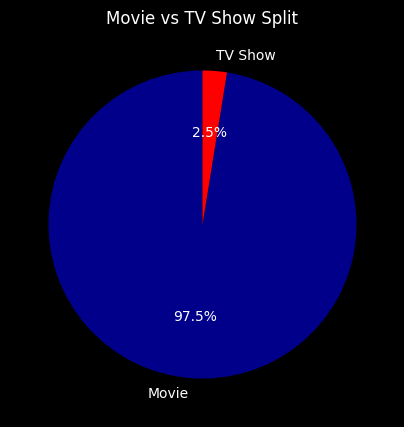

In [30]:
import matplotlib.pyplot as plt
type_counts = n['type'].value_counts()

plt.figure(figsize=(5,5), facecolor='black')

plt.pie(
    type_counts,
    labels=type_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['darkblue','red'],
    textprops={'color': 'white'}
)

plt.title('Movie vs TV Show Split', color='white', fontsize=12)
plt.show()

In [31]:
#content_added_per_year_type
CAPYT= n.groupby(['year_added', 'type']).size().reset_index(name='title')
print(CAPYT)

    year_added     type  title
0       2008.0    Movie      1
1       2009.0    Movie      2
2       2010.0    Movie      1
3       2011.0    Movie     13
4       2012.0    Movie      4
5       2013.0    Movie      6
6       2013.0  TV Show      1
7       2014.0    Movie     14
8       2015.0    Movie     47
9       2015.0  TV Show      2
10      2016.0    Movie    204
11      2016.0  TV Show      5
12      2017.0    Movie    778
13      2017.0  TV Show     17
14      2018.0    Movie   1122
15      2018.0  TV Show     15
16      2019.0    Movie   1347
17      2019.0  TV Show     24
18      2020.0    Movie    139
19      2020.0  TV Show      1


In [32]:
content_per_year = n.groupby(['year_added', 'type']).size().unstack(fill_value=0)
print(content_per_year)

type        Movie  TV Show
year_added                
2008.0          1        0
2009.0          2        0
2010.0          1        0
2011.0         13        0
2012.0          4        0
2013.0          6        1
2014.0         14        0
2015.0         47        2
2016.0        204        5
2017.0        778       17
2018.0       1122       15
2019.0       1347       24
2020.0        139        1


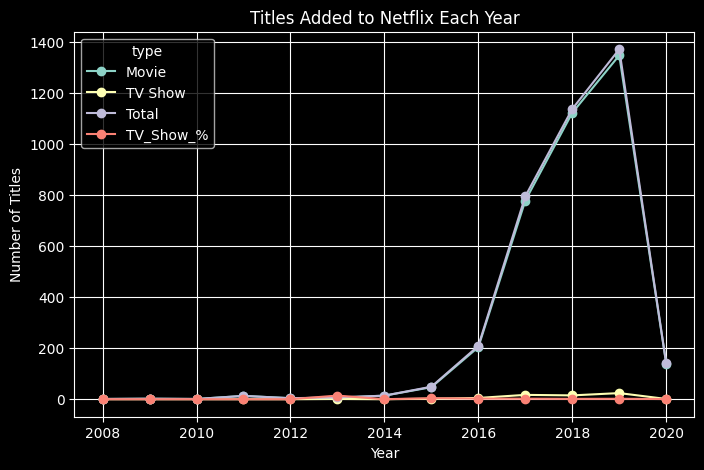

In [98]:
import matplotlib.pyplot as plt

content_per_year.plot(figsize=(8,5), marker='o')
plt.title('Titles Added to Netflix Each Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.grid(True)
plt.show()

In [34]:
content_per_year['Total'] = content_per_year['Movie'] + content_per_year['TV Show']
content_per_year['TV_Show_%'] = ((content_per_year['TV Show'] / content_per_year['Total']) * 100).round(3)
print(content_per_year)

type        Movie  TV Show  Total  TV_Show_%
year_added                                  
2008.0          1        0      1      0.000
2009.0          2        0      2      0.000
2010.0          1        0      1      0.000
2011.0         13        0     13      0.000
2012.0          4        0      4      0.000
2013.0          6        1      7     14.286
2014.0         14        0     14      0.000
2015.0         47        2     49      4.082
2016.0        204        5    209      2.392
2017.0        778       17    795      2.138
2018.0       1122       15   1137      1.319
2019.0       1347       24   1371      1.751
2020.0        139        1    140      0.714


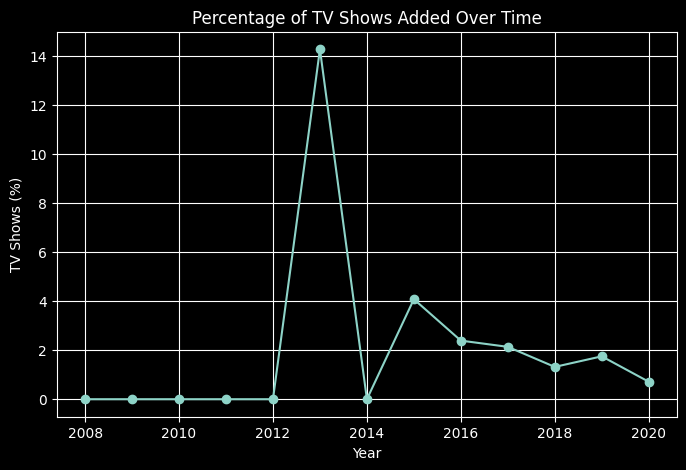

In [35]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(content_per_year.index, content_per_year['TV_Show_%'], marker='o')

plt.title('Percentage of TV Shows Added Over Time')
plt.xlabel('Year')
plt.ylabel('TV Shows (%)')

plt.grid(True)
plt.show()

In [36]:
titles_per_year=n['year_added'].value_counts().sort_index()
print(titles_per_year)

year_added
2008.0       1
2009.0       2
2010.0       1
2011.0      13
2012.0       4
2013.0       7
2014.0      14
2015.0      49
2016.0     209
2017.0     795
2018.0    1137
2019.0    1371
2020.0     140
Name: count, dtype: int64


In [37]:
max_year = titles_per_year.idxmax() #idmax=return index (the year) with the maximum value.
max_count = titles_per_year.max()   #Returns the maximum number of titles

print(max_year)
print(max_count)

2019.0
1371


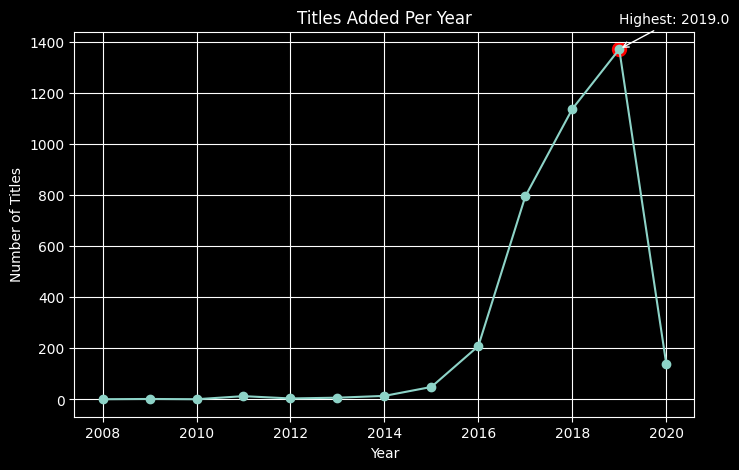

In [96]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

plt.plot(titles_per_year.index, titles_per_year.values, marker='o')

plt.scatter(max_year, max_count, color='red', s=100)

# Add annotation
plt.annotate(
    f'Highest: {max_year}',
    xy=(max_year, max_count),
    xytext=(max_year, max_count + 100),
    arrowprops=dict(arrowstyle='->')
)

plt.title('Titles Added Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles')

plt.grid(True)
plt.savefig('title_added_per_year.png')
plt.show()

In [39]:
n.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3774 entries, 0 to 6213
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   show_id           3774 non-null   int64         
 1   type              3774 non-null   object        
 2   title             3774 non-null   object        
 3   director          3774 non-null   object        
 4   cast              3774 non-null   object        
 5   country           3774 non-null   object        
 6   date_added        3743 non-null   datetime64[ns]
 7   release_year      3774 non-null   int64         
 8   rating            3774 non-null   object        
 9   duration          3774 non-null   object        
 10  listed_in         3774 non-null   object        
 11  description       3774 non-null   object        
 12  year_added        3743 non-null   float64       
 13  month_added       3743 non-null   float64       
 14  duration_seasons  96 non-null

In [40]:
n['age_gap']=n['year_added']-n['release_year']
print(n['age_gap'])

0       0.0
4       0.0
6       3.0
7       0.0
9       3.0
       ... 
6142    NaN
6158    NaN
6167    NaN
6182    NaN
6213    NaN
Name: age_gap, Length: 3774, dtype: float64


In [41]:
average_gap = n['age_gap'].mean(). round(3)

print("Average Gap:", average_gap)

Average Gap: 5.964


#Module 3 — Genre, Country & Ratings Analysis  (2–3 hours)
Goal:  Analyze multi-valued categorical fields correctly using string splitting and explode()
Difficulty:  Intermediate – this is the trickiest module

* Tasks — Genre Analysis
15.	Split listed_in by comma and use df.explode() to turn each genre into its own row (one title can belong to multiple genres)
16.	Count occurrences of each genre using value_counts() on the exploded column
17.	Plot the Top 10 genres as a horizontal bar chart

* Tasks — Country Analysis
18.	Apply the same split + explode() technique to the country column
19.	Count titles by country — plot Top 10 content-producing countries
20.	Compute and plot what percentage of total content is the United States vs Rest of World

* Tasks — Ratings Analysis
21.	Plot the distribution of rating (content classification) as a bar chart
22.	Group ratings into broader categories: Kids (TV-Y, TV-G, G), Teens (PG-13, TV-14), Adults (R, TV-MA) using a mapping dictionary
23.	Plot the Kids/Teens/Adults split as a pie chart



In [42]:
n['listed_in']

,listed_in
0,"Children & Family Movies, Comedies"
4,Comedies
6,"International Movies, Sci-Fi & Fantasy, Thrillers"
7,Stand-Up Comedy
9,"Action & Adventure, Thrillers"
...,...
6142,"British TV Shows, Reality TV"
6158,"Kids' TV, TV Action & Adventure"
6167,"Crime TV Shows, International TV Shows, TV Dramas"
6182,"International TV Shows, Korean TV Shows, Stand..."


In [55]:
# n.explode('listed_in')
# # n['listed_in']
# n['listed_in'].value_counts()


n['listed_in'] = n['listed_in'].str.split(', ')

n = n.explode('listed_in')

print(n['listed_in'].value_counts())

In [57]:
n['primary_genre'].value_counts()

,count
primary_genre,
Dramas,2548
Comedies,1943
Action & Adventure,1418
Children & Family Movies,574
Documentaries,486
Horror Movies,423
Stand-Up Comedy,234
International Movies,169
Classic Movies,149


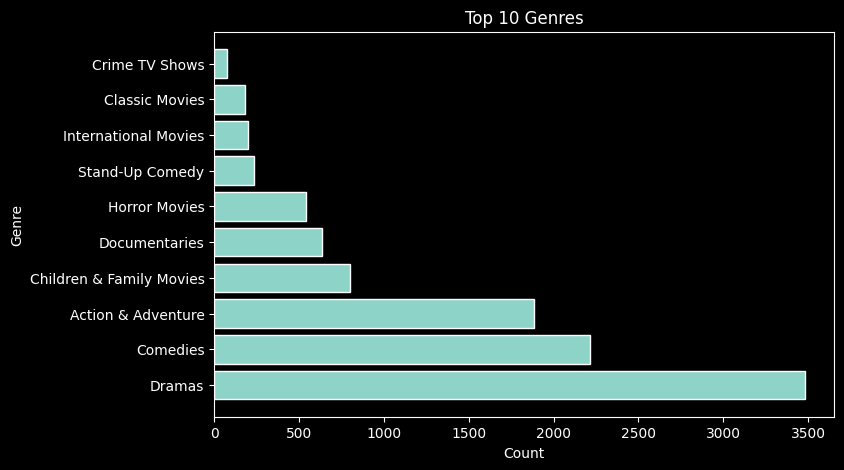

In [94]:
import matplotlib.pyplot as plt
genre_counts = n['primary_genre'].value_counts().head(10)
plt.figure(figsize=(8,5))
plt.barh(genre_counts.index, genre_counts.values,
         edgecolor="white")
plt.title('Top 10 Genres')
plt.xlabel('Count')
plt.ylabel('Genre')

plt.savefig('top_10_genres.png')
plt.show()

In [64]:
n['country']

,country
0,"United States, India, South Korea, China"
0,"United States, India, South Korea, China"
4,United States
6,"Bulgaria, United States, Spain, Canada"
6,"Bulgaria, United States, Spain, Canada"
...,...
6182,South Korea
6182,South Korea
6213,Turkey
6213,Turkey


In [66]:
n['country'] = n['country'].str.split(', ')

n = n.explode('country')

display(n['country'].value_counts())

,count
country,
United States,3190
India,2083
United Kingdom,713
France,466
Canada,397
...,...
Kenya,1
Sudan,1
Nicaragua,1


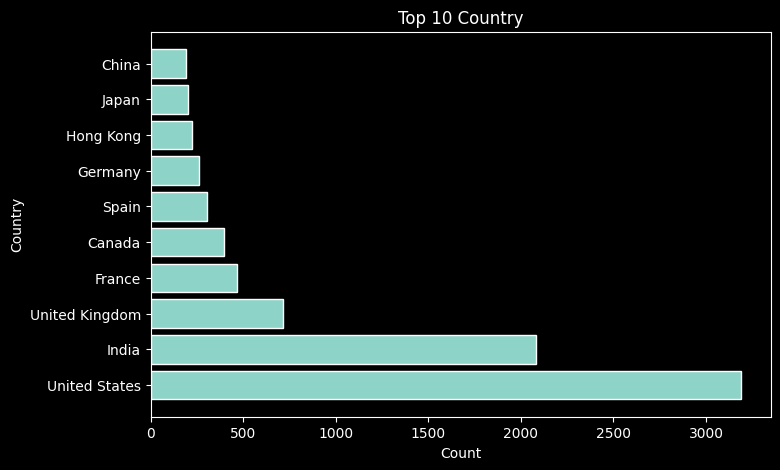

In [68]:

import matplotlib.pyplot as plt
country_counts = n['country'].value_counts().head(10)
plt.figure(figsize=(8,5))
plt.barh(country_counts.index, country_counts.values,
         edgecolor="white")
plt.title('Top 10 Country')
plt.xlabel('Count')
plt.ylabel('Country')
plt.show()

In [70]:
country_group = n['country'].apply(
    lambda x: 'United States' if pd.notna(x) and 'United States' in x else 'Rest of World'
)
counts = country_group.value_counts()

us_percent = ((counts['United States'] / len(n)) * 100).round(3)
rest_percent = ((counts['Rest of World'] / len(n)) * 100).round(3)

print("United States:", us_percent)
print("Rest of World:", rest_percent)

United States: 29.791
Rest of World: 70.209


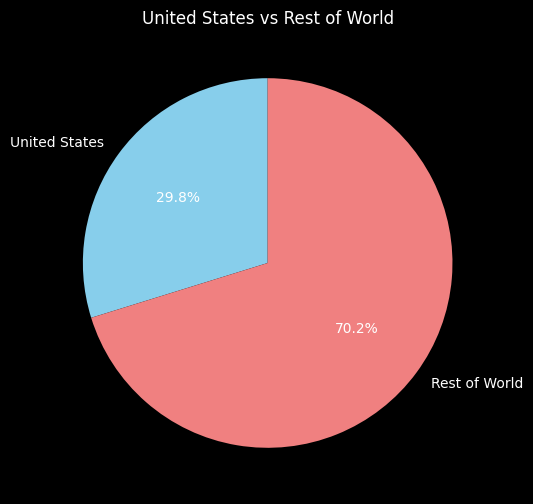

In [99]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.pie(
    [us_percent, rest_percent], # Data for the pie chart
    labels=['United States', 'Rest of World'], # Labels for each slice
    autopct='%1.1f%%',
    startangle=90,
    colors=['skyblue', 'lightcoral'] # Optional: add colors for better visualization
)

plt.title('United States vs Rest of World')
plt.savefig('us_vs_rest.png')
plt.show()

In [78]:
dis_rating=n['rating'].value_counts()

,count
rating,
TV-MA,3172
TV-14,2541
R,1623
TV-PG,986
PG-13,951
PG,548
NR,489
TV-G,115
TV-Y7,98


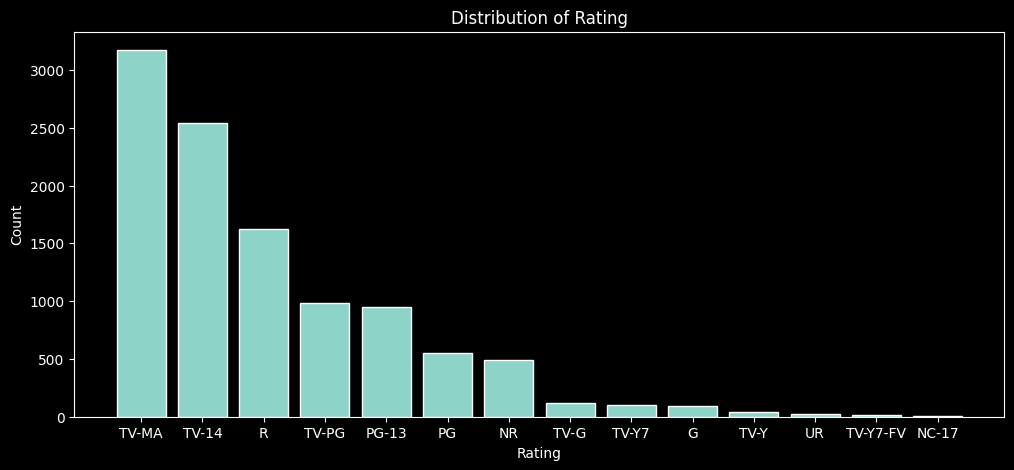

In [100]:
import matplotlib.pyplot as plt

dis_rating = n['rating'].value_counts() # Define dis_rating here

plt.figure(figsize=(12,5))
plt.bar(dis_rating.index, dis_rating.values,
        edgecolor="white")
plt.title('Distribution of Rating')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.savefig('distribution_of_rating.png')
plt.show()

In [86]:
group_rating={
    'Kids': ['TV-Y', 'TV-G', 'G'],
    'Teens': ['PG-13', 'TV-14'],
    'Adults': ['R', 'TV-MA']
}
n['rating_group'] = n['rating'].apply(
    lambda x: next((group for group, ratings in group_rating.items() if x in ratings), 'Other')
)
rating_group_counts = n['rating_group'].value_counts()
print(rating_group_counts)

rating_group
Adults    4795
Teens     3492
Other     2173
Kids       248
Name: count, dtype: int64


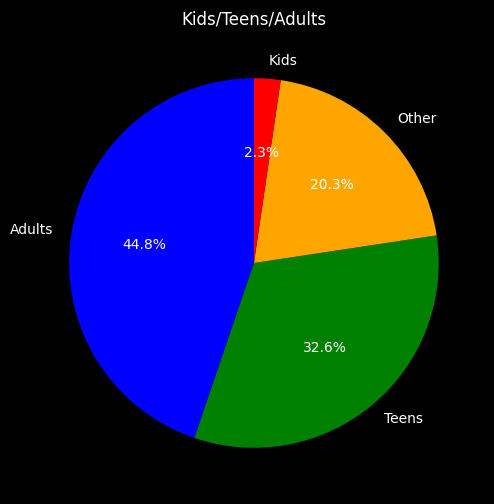

In [101]:
plt.figure(figsize=(6,6))
plt.pie(
    rating_group_counts,
    labels=rating_group_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['blue', 'green', 'orange', 'red']
)
plt.title('Kids/Teens/Adults')
plt.savefig('kids_teens_adults.png')
plt.show()